# Student Outcome Classification — Portfolio ML Project

## Project objective
Predict the student's **Target** outcome (`Dropout`, `Enrolled`, or `Graduate`) using a technically defensible multiclass classification workflow.

**Important modeling decision:** the dataset contains first- and second-semester academic variables. Those variables are observed after enrollment and may be very close in time to the final outcome. To avoid temporal leakage for an **early-warning** use case, the primary model uses only non-curricular features that are available from the administrative/demographic/economic part of the dataset.

This notebook preserves the original data and does not artificially add/remove observations.

## What / Why / Meaning

- **What?** Inspect the data, understand the target, perform meaningful EDA, build leakage-safe preprocessing, compare models, validate them, tune the most promising model, and interpret it.
- **Why?** A portfolio project should demonstrate correct methodology, not only a high accuracy score.
- **Meaning:** Every modeling decision is made using the training data only; the held-out test set is used at the end for final evaluation.

In [3]:
# Core libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_validate, GridSearchCV
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    classification_report, confusion_matrix, ConfusionMatrixDisplay
)

RANDOM_STATE = 42


## 1. Load the dataset

The original file is loaded without changing its rows or columns.

In [4]:
# Load the original dataset
df = pd.read_csv("dataset.csv")

df.head()

,Marital status,Application mode,Application order,Course,Daytime/evening attendance,Previous qualification,Nacionality,Mother's qualification,Father's qualification,Mother's occupation,...,Curricular units 2nd sem (credited),Curricular units 2nd sem (enrolled),Curricular units 2nd sem (evaluations),Curricular units 2nd sem (approved),Curricular units 2nd sem (grade),Curricular units 2nd sem (without evaluations),Unemployment rate,Inflation rate,GDP,Target
0,1,8,5,2,1,1,1,13,10,6,...,0,0,0,0,0.000000,0,10.8,1.4,1.74,Dropout
1,1,6,1,11,1,1,1,1,3,4,...,0,6,6,6,13.666667,0,13.9,-0.3,0.79,Graduate
2,1,1,5,5,1,1,1,22,27,10,...,0,6,0,0,0.000000,0,10.8,1.4,1.74,Dropout
3,1,8,2,15,1,1,1,23,27,6,...,0,6,10,5,12.400000,0,9.4,-0.8,-3.12,Graduate
4,2,12,1,3,0,1,1,22,28,10,...,0,6,6,6,13.000000,0,13.9,-0.3,0.79,Graduate


## 2. Dataset overview

First establish the basic structure before making any modeling decision.

In [5]:
print("Shape:", df.shape)
print("\nColumns:")
print(df.columns.tolist())

print("\nData types:")
display(df.dtypes.to_frame("dtype"))

print("\nDescriptive statistics:")
display(df.describe(include="all").T)

Shape: (4424, 35)

Columns:
['Marital status', 'Application mode', 'Application order', 'Course', 'Daytime/evening attendance', 'Previous qualification', 'Nacionality', "Mother's qualification", "Father's qualification", "Mother's occupation", "Father's occupation", 'Displaced', 'Educational special needs', 'Debtor', 'Tuition fees up to date', 'Gender', 'Scholarship holder', 'Age at enrollment', 'International', 'Curricular units 1st sem (credited)', 'Curricular units 1st sem (enrolled)', 'Curricular units 1st sem (evaluations)', 'Curricular units 1st sem (approved)', 'Curricular units 1st sem (grade)', 'Curricular units 1st sem (without evaluations)', 'Curricular units 2nd sem (credited)', 'Curricular units 2nd sem (enrolled)', 'Curricular units 2nd sem (evaluations)', 'Curricular units 2nd sem (approved)', 'Curricular units 2nd sem (grade)', 'Curricular units 2nd sem (without evaluations)', 'Unemployment rate', 'Inflation rate', 'GDP', 'Target']

Data types:


,dtype
Marital status,int64
Application mode,int64
Application order,int64
Course,int64
Daytime/evening attendance,int64
Previous qualification,int64
Nacionality,int64
Mother's qualification,int64
Father's qualification,int64
Mother's occupation,int64



Descriptive statistics:


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Marital status,4424.0,NaN,NaN,NaN,1.178571,0.605747,1.0,1.0,1.0,1.0,6.0
Application mode,4424.0,NaN,NaN,NaN,6.88698,5.298964,1.0,1.0,8.0,12.0,18.0
Application order,4424.0,NaN,NaN,NaN,1.727848,1.313793,0.0,1.0,1.0,2.0,9.0
Course,4424.0,NaN,NaN,NaN,9.899186,4.331792,1.0,6.0,10.0,13.0,17.0
Daytime/evening attendance,4424.0,NaN,NaN,NaN,0.890823,0.311897,0.0,1.0,1.0,1.0,1.0
Previous qualification,4424.0,NaN,NaN,NaN,2.53142,3.963707,1.0,1.0,1.0,1.0,17.0
Nacionality,4424.0,NaN,NaN,NaN,1.254521,1.748447,1.0,1.0,1.0,1.0,21.0
Mother's qualification,4424.0,NaN,NaN,NaN,12.322107,9.026251,1.0,2.0,13.0,22.0,29.0
Father's qualification,4424.0,NaN,NaN,NaN,16.455244,11.0448,1.0,3.0,14.0,27.0,34.0
Mother's occupation,4424.0,NaN,NaN,NaN,7.317812,3.997828,1.0,5.0,6.0,10.0,32.0


### Data quality checks

In [6]:
# Missing values
missing = df.isna().sum().sort_values(ascending=False)
print("Total missing values:", int(missing.sum()))
display(missing[missing > 0].to_frame("missing_count"))

# Duplicate rows
print("Duplicate rows:", df.duplicated().sum())

# Unique values
display(df.nunique().sort_values().to_frame("unique_values"))

Total missing values: 0


,missing_count


Duplicate rows: 0


,unique_values
Daytime/evening attendance,2
Debtor,2
Tuition fees up to date,2
Gender,2
Educational special needs,2
Displaced,2
International,2
Scholarship holder,2
Target,3
Marital status,6


### Audit interpretation

The supplied dataset contains **4,424 rows and 35 columns**. In the supplied file, there are no missing values and no duplicate rows. The target is a three-class categorical variable.

The integer dtype of many columns does **not** mean those columns should be treated as continuous numerical measurements. Several are coded categories (for example, application mode, course, qualification, occupation, and nationality), so the modeling pipeline treats them as categorical.

## 3. Target analysis

,count,percentage
Target,,
Graduate,2209,49.93
Dropout,1421,32.12
Enrolled,794,17.95


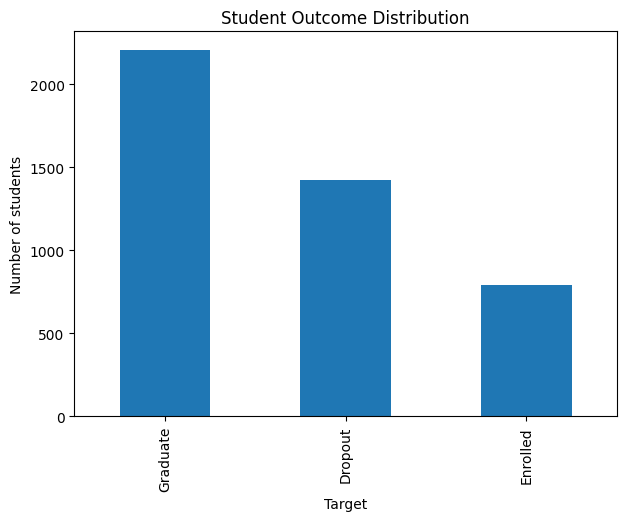

In [7]:
target_counts = df["Target"].value_counts()
target_pct = df["Target"].value_counts(normalize=True).mul(100).round(2)

target_summary = pd.DataFrame({
    "count": target_counts,
    "percentage": target_pct
})
display(target_summary)

plt.figure(figsize=(7, 5))
target_counts.reindex(target_counts.index).plot(kind="bar", ax=plt.gca())
plt.title("Student Outcome Distribution")
plt.xlabel("Target")
plt.ylabel("Number of students")
plt.show()

### Interpretation

The target classes are **Graduate, Dropout, and Enrolled**. The class distribution is not balanced: Graduate is the largest class and Enrolled is the smallest. Therefore, accuracy alone can hide poor performance on the minority class.

For model selection, **macro F1** is important because it gives each class equal weight.

## 4. Data type and feature-role audit

The dataset uses integer codes for many categorical variables. We explicitly define their roles rather than relying on pandas dtype alone.

In [8]:
# Preliminary role definitions used for EDA. The authoritative final feature list is finalized in Section 9.
target_column = "Target"
temporal_leakage_features = [
    col for col in df.columns if col.startswith("Curricular units")
]
identifier_features = [
    col for col in df.columns
    if col.lower() in {"id", "student_id", "studentid", "index"}
]
numeric_features = [
    "Age at enrollment",
    "Unemployment rate",
    "Inflation rate",
    "GDP"
]
candidate_feature_columns = [
    col for col in df.columns
    if col not in {target_column, *temporal_leakage_features, *identifier_features}
]
categorical_features = [col for col in candidate_feature_columns if col not in numeric_features]

print("Preliminary categorical features:", len(categorical_features))
print("Preliminary numerical features:", len(numeric_features))
print("Potential leakage features:", len(temporal_leakage_features))
display(pd.DataFrame({
    "Feature": categorical_features + numeric_features,
    "Role": (["Categorical"] * len(categorical_features)) + (["Numerical"] * len(numeric_features))
}))


Preliminary categorical features: 18
Preliminary numerical features: 4
Potential leakage features: 12


,Feature,Role
0,Marital status,Categorical
1,Application mode,Categorical
2,Application order,Categorical
3,Course,Categorical
4,Daytime/evening attendance,Categorical
5,Previous qualification,Categorical
6,Nacionality,Categorical
7,Mother's qualification,Categorical
8,Father's qualification,Categorical
9,Mother's occupation,Categorical


## 5. Exploratory data analysis

Only plots that answer a modeling or data-understanding question are included.

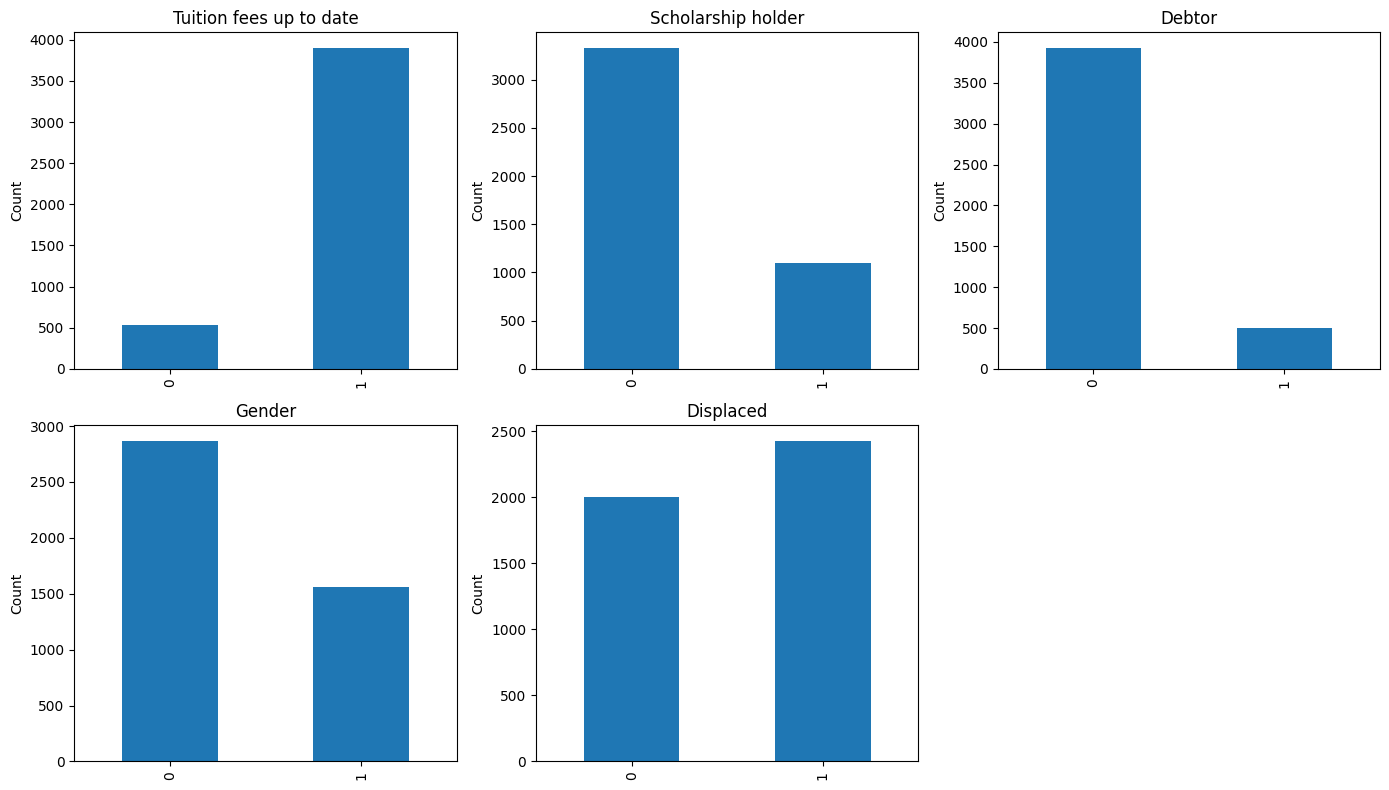

In [9]:
# A small set of meaningful binary/categorical distributions
eda_cols = [
    "Tuition fees up to date",
    "Scholarship holder",
    "Debtor",
    "Gender",
    "Displaced"
]

fig, axes = plt.subplots(2, 3, figsize=(14, 8))
for ax, col in zip(axes.flat, eda_cols):
    df[col].value_counts().sort_index().plot(kind="bar", ax=ax)
    ax.set_title(col)
    ax.set_xlabel("")
    ax.set_ylabel("Count")
axes.flat[-1].axis("off")
plt.tight_layout()
plt.show()

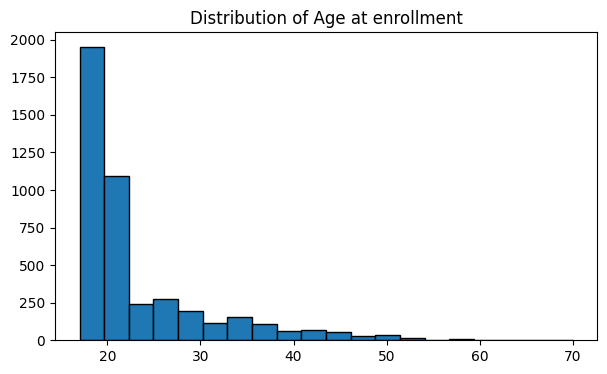

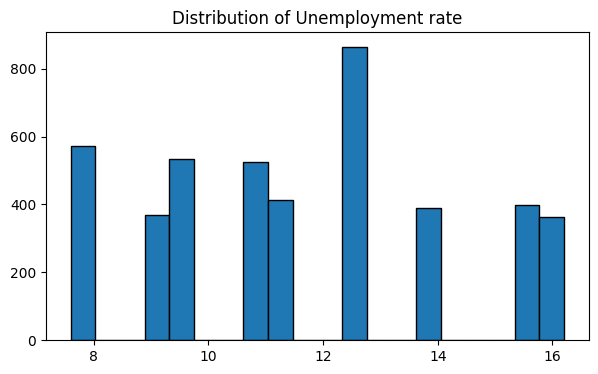

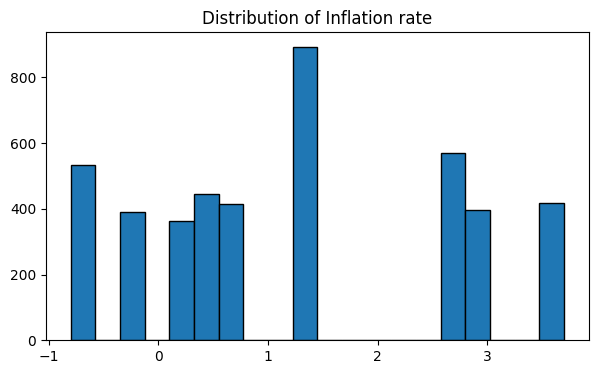

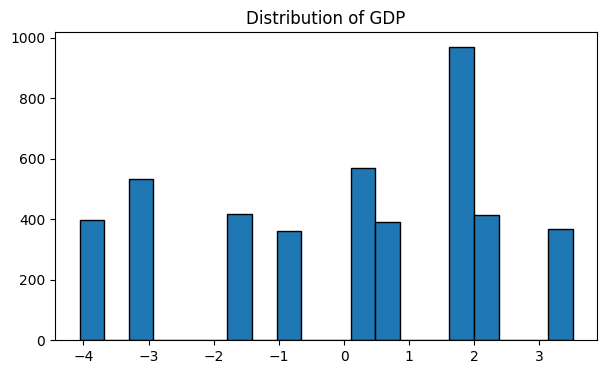

In [10]:
# Numerical distributions that are genuinely continuous/quantitative
for col in numeric_features:
    plt.figure(figsize=(7, 4))
    plt.hist(df[col].dropna(), bins=20, edgecolor="black")
    plt.title(f"Distribution of {col}")
    plt.show()

### Feature vs target: categorical relationships


Tuition fees up to date vs Target — row percentages


Target,Dropout,Enrolled,Graduate
Tuition fees up to date,,,
0,86.6,8.0,5.5
1,24.7,19.3,56.0


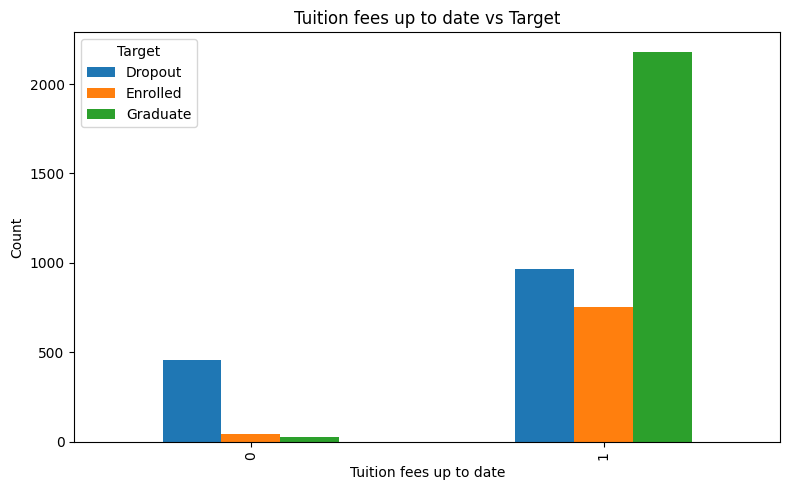


Scholarship holder vs Target — row percentages


Target,Dropout,Enrolled,Graduate
Scholarship holder,,,
0,38.7,20.0,41.3
1,12.2,11.8,76.0


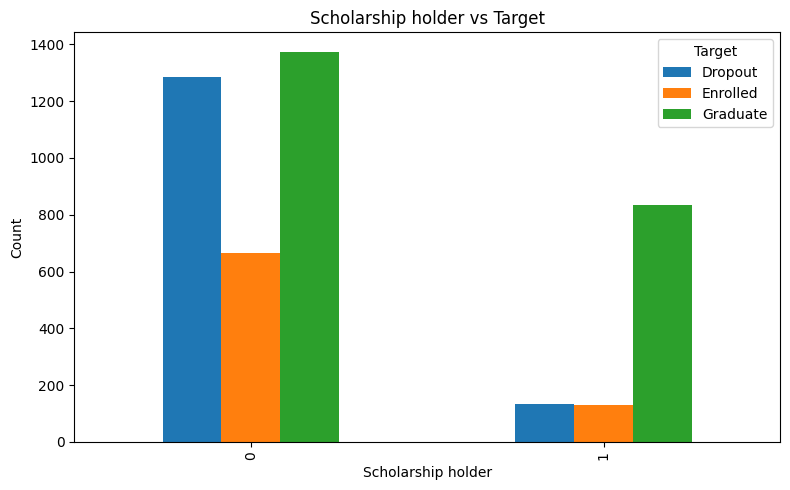


Debtor vs Target — row percentages


Target,Dropout,Enrolled,Graduate
Debtor,,,
0,28.3,18.0,53.8
1,62.0,17.9,20.1


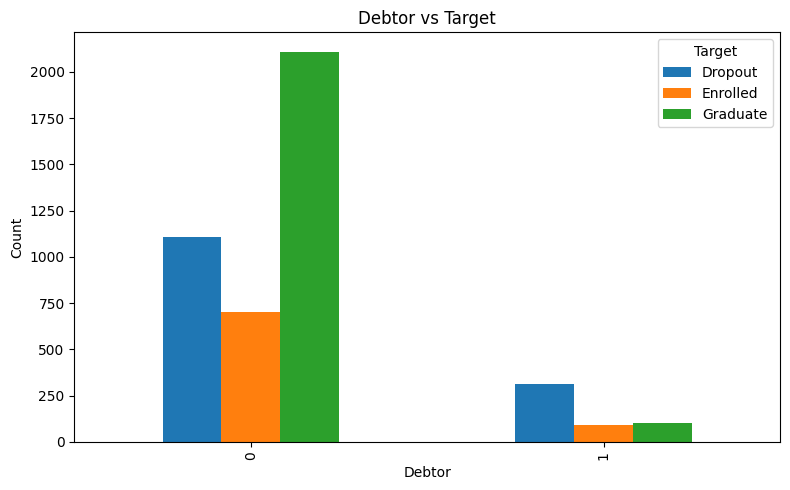


Gender vs Target — row percentages


Target,Dropout,Enrolled,Graduate
Gender,,,
0,25.1,17.0,57.9
1,45.1,19.7,35.2


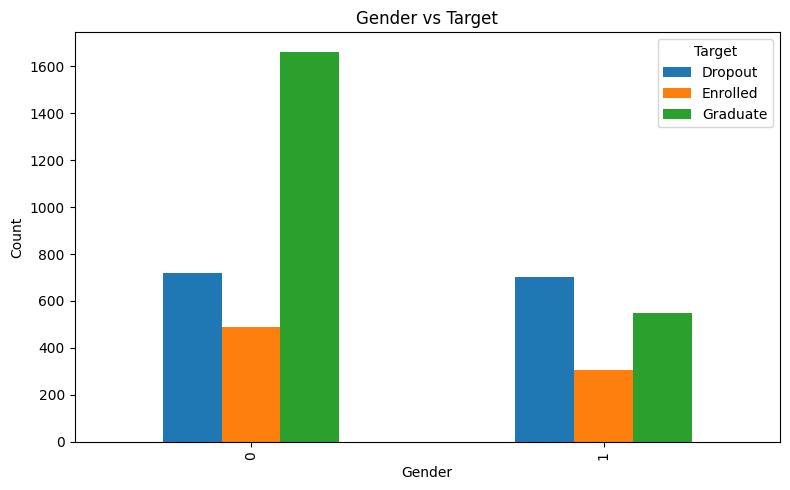

In [11]:
# Row-wise percentages answer: "Within this feature value, how are outcomes distributed?"
for col in [
    "Tuition fees up to date",
    "Scholarship holder",
    "Debtor",
    "Gender"
]:
    print(f"\n{col} vs Target — row percentages")
    display(pd.crosstab(df[col], df["Target"], normalize="index").mul(100).round(1))

    plt.figure(figsize=(8, 5))
    pd.crosstab(df[col], df["Target"]).plot(kind="bar", ax=plt.gca())
    plt.title(f"{col} vs Target")
    plt.xlabel(col)
    plt.ylabel("Count")
    plt.legend(title="Target")
    plt.tight_layout()
    plt.show()

### Higher-cardinality categorical features

Course and application mode are useful to inspect because their coded values represent distinct categories, not numerical distances.

In [12]:
for col in ["Course", "Application mode"]:
    table = pd.crosstab(df[col], df["Target"], normalize="index").mul(100).round(1)
    print(f"\n{col} vs Target — row percentages")
    display(table)


Course vs Target — row percentages


Target,Dropout,Enrolled,Graduate
Course,,,
1,66.7,25.0,8.3
2,38.1,17.2,44.7
3,33.0,9.8,57.2
4,41.0,17.6,41.4
5,22.6,18.6,58.8
6,26.7,22.3,51.0
7,54.1,37.6,8.2
8,55.3,14.9,29.8
9,35.3,28.4,36.3



Application mode vs Target — row percentages


Target,Dropout,Enrolled,Graduate
Application mode,,,
1,20.2,17.6,62.2
2,66.7,0.0,33.3
3,12.5,50.0,37.5
4,61.2,5.0,33.8
5,30.0,0.0,70.0
6,16.7,33.3,50.0
7,13.2,21.1,65.8
8,29.4,18.2,52.4
9,36.3,12.9,50.8


### Numerical features vs target

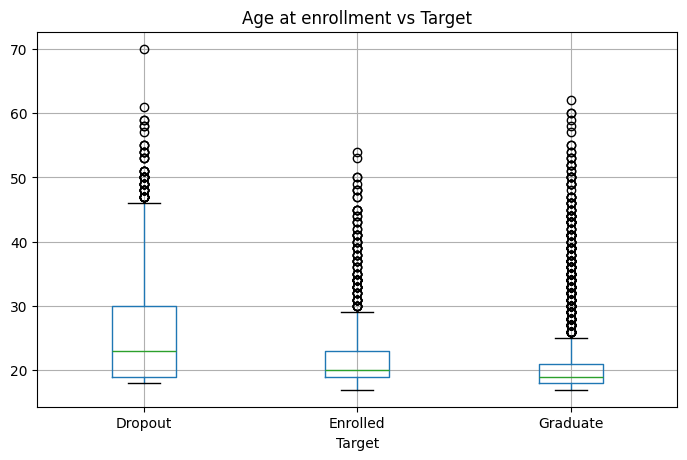

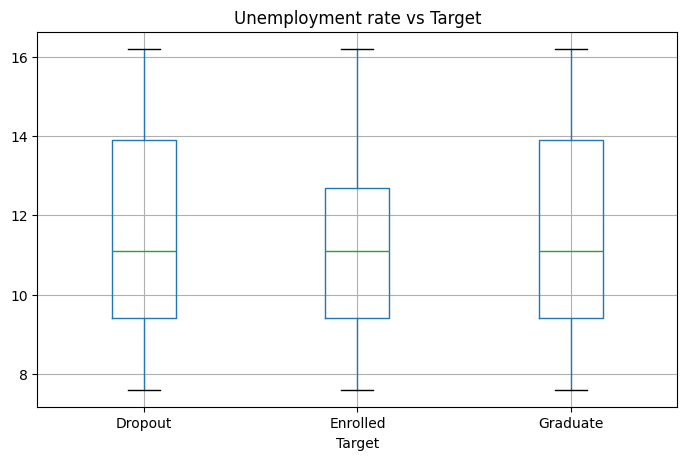

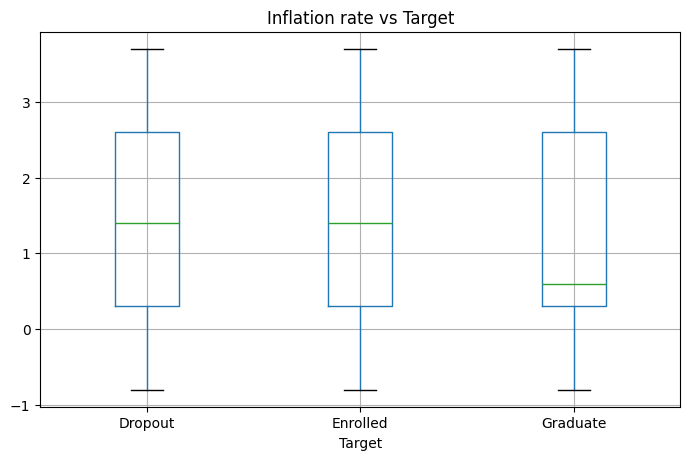

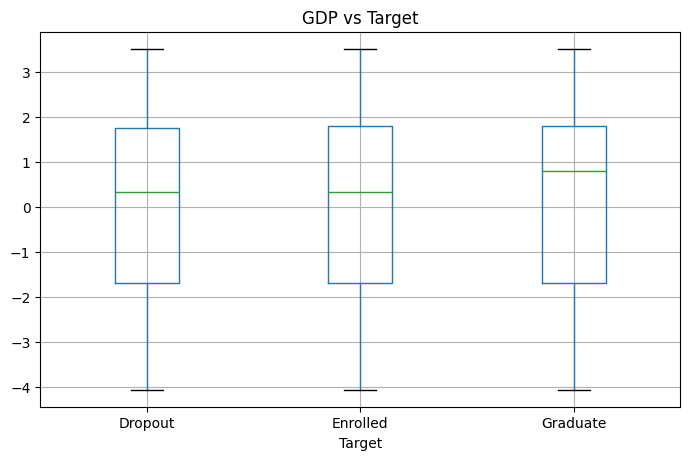

In [13]:
for col in numeric_features:
    plt.figure(figsize=(8, 5))
    df.boxplot(column=col, by="Target", ax=plt.gca())
    plt.title(f"{col} vs Target")
    plt.suptitle("")
    plt.show()

## 6. Correlation analysis

Pearson correlation is appropriate here only for genuinely numerical variables. It is **not** applied blindly to integer-coded categorical variables.

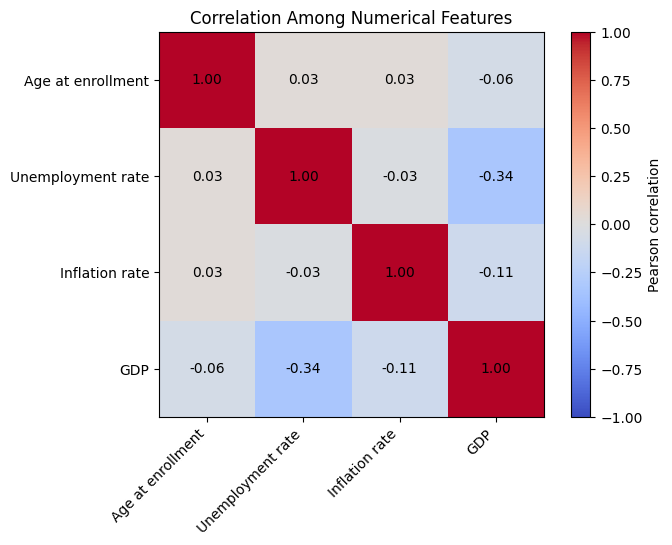

,Age at enrollment,Unemployment rate,Inflation rate,GDP
Age at enrollment,1.000000,0.025018,0.025377,-0.064678
Unemployment rate,0.025018,1.000000,-0.028885,-0.335178
Inflation rate,0.025377,-0.028885,1.000000,-0.112295
GDP,-0.064678,-0.335178,-0.112295,1.000000


In [14]:
corr = df[numeric_features].corr()

plt.figure(figsize=(7, 5))
plt.imshow(corr.values, cmap="coolwarm", vmin=-1, vmax=1)
plt.colorbar(label="Pearson correlation")
plt.xticks(range(len(corr.columns)), corr.columns, rotation=45, ha="right")
plt.yticks(range(len(corr.index)), corr.index)
for i in range(len(corr.index)):
    for j in range(len(corr.columns)):
        plt.text(j, i, f"{corr.iloc[i, j]:.2f}", ha="center", va="center")
plt.title("Correlation Among Numerical Features")
plt.show()

display(corr)

## 7. Outlier review

Outlier detection is a diagnostic step, not an automatic deletion rule. Extreme values are retained unless there is evidence that they are invalid.

In [15]:
for col in numeric_features:
    q1 = df[col].quantile(0.25)
    q3 = df[col].quantile(0.75)
    iqr = q3 - q1
    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr
    n_outliers = ((df[col] < lower) | (df[col] > upper)).sum()

    print(f"{col}: {n_outliers} IQR-flagged observations; limits = ({lower:.2f}, {upper:.2f})")

Age at enrollment: 441 IQR-flagged observations; limits = (10.00, 34.00)
Unemployment rate: 0 IQR-flagged observations; limits = (2.65, 20.65)
Inflation rate: 0 IQR-flagged observations; limits = (-3.15, 6.05)
GDP: 0 IQR-flagged observations; limits = (-6.94, 7.03)


**Decision:** keep the original observations. An IQR flag does not prove that an observation is erroneous, and the project rules require preserving valid observations.

## 8. Data leakage check

This is a key issue in this dataset.

The curricular-unit variables describe first- and second-semester academic activity. If the intended prediction is made **at enrollment**, those variables are unavailable at prediction time and would create temporal leakage.

They are therefore excluded from the primary early-warning model.

This is not the same as saying the variables are "bad" data. They are useful for a different prediction-time definition, such as a later student-monitoring model.

In [16]:
# Explicit leakage/timing audit
leakage_audit = pd.DataFrame([
    ["Target", "Not an input feature", "The label being predicted."],
    ["1st-semester curricular variables", "Exclude from early-warning model",
     "Observed after enrollment; unavailable at enrollment."],
    ["2nd-semester curricular variables", "Exclude from early-warning model",
     "Observed later still; unavailable at enrollment."],
    ["Administrative/demographic coded variables", "Keep as categorical",
     "Meaningful coded categories available at the intended prediction stage."],
    ["Age at enrollment", "Keep as numerical",
     "Genuine quantitative measurement available at enrollment."],
    ["Unemployment/Inflation/GDP", "Keep as numerical",
     "Quantitative economic indicators included in the supplied data."]
], columns=["Feature group", "Decision", "Reason"])
display(leakage_audit)


,Feature group,Decision,Reason
0,Target,Not an input feature,The label being predicted.
1,1st-semester curricular variables,Exclude from early-warning model,Observed after enrollment; unavailable at enro...
2,2nd-semester curricular variables,Exclude from early-warning model,Observed later still; unavailable at enrollment.
3,Administrative/demographic coded variables,Keep as categorical,Meaningful coded categories available at the i...
4,Age at enrollment,Keep as numerical,Genuine quantitative measurement available at ...
5,Unemployment/Inflation/GDP,Keep as numerical,Quantitative economic indicators included in t...


## 9. Feature audit — original columns → removed columns → final modeling columns

This audit is performed before the train/test split. A column is not removed merely because it is an integer code, has few unique values, or has a weak simple correlation.

### Prediction point
The primary model is an **enrollment-time early-warning model**. Therefore, a predictor must be available at or around admission/enrollment. First- and second-semester curricular-performance variables are excluded because they are observed after enrollment.

### Removal categories
1. **Target:** `Target` is not an input feature; it is the label `y`.
2. **Temporal leakage:** all 12 `Curricular units ...` variables are excluded from the primary model.
3. **Identifiers:** any obvious ID/index column would be removed, but none is present in the supplied 35-column schema.
4. **Constant/near-constant:** constant columns are removed if present. Near-constant variables are reviewed but are **not automatically deleted**; in this dataset, rare binary indicators such as `Educational special needs` and `International` are retained because they can still carry predictive information and are not constant.

The original `df` is never altered. Only the modeling matrix `X` is reduced.


In [17]:
target_column = "Target"

# Variables observed after enrollment: excluded from the primary early-warning model.
temporal_leakage_features = [
    col for col in df.columns if col.startswith("Curricular units")
]

# Obvious administrative identifiers, if present. None are expected in the supplied dataset.
identifier_features = [
    col for col in df.columns
    if col.lower() in {"id", "student_id", "studentid", "index"}
]

# Genuine continuous/numerical variables.
numeric_features = [
    "Age at enrollment",
    "Unemployment rate",
    "Inflation rate",
    "GDP"
]

# All remaining non-target, non-leakage, non-identifier columns are retained.
final_feature_columns = [
    col for col in df.columns
    if col not in {target_column, *temporal_leakage_features, *identifier_features}
]

categorical_features = [
    col for col in final_feature_columns if col not in numeric_features
]

# Constant-column audit: detect, report, and remove only genuinely constant predictors.
constant_features = [
    col for col in final_feature_columns if df[col].nunique(dropna=False) <= 1
]

# Remove constants from the final modeling list if any exist.
final_feature_columns = [col for col in final_feature_columns if col not in constant_features]
categorical_features = [col for col in categorical_features if col not in constant_features]
numeric_features = [col for col in numeric_features if col not in constant_features]

# Near-constant review (99%+ in one value) is diagnostic only; it is not an automatic deletion rule.
near_constant_rows = []
for col in final_feature_columns:
    top_share = df[col].value_counts(normalize=True, dropna=False).iloc[0]
    if top_share >= 0.99:
        near_constant_rows.append({
            "Feature": col,
            "Most common value share": round(float(top_share), 4),
            "Decision": "Retain — not constant; predictive usefulness should be assessed by the model."
        })
near_constant_review = pd.DataFrame(near_constant_rows)

# Complete audit trail for every original column.
audit_rows = []
for col in df.columns:
    if col == target_column:
        decision, category, reason = (
            "Not a feature", "Target", "This is the outcome label being predicted; kept separately as y."
        )
    elif col in identifier_features:
        decision, category, reason = (
            "Remove", "Identifier", "Administrative identifier with no meaningful student characteristic."
        )
    elif col in temporal_leakage_features:
        semester = "1st-semester" if "1st sem" in col else "2nd-semester"
        decision, category, reason = (
            "Remove from primary model", "Temporal leakage",
            f"{semester} academic activity is observed after enrollment and is unavailable at the enrollment-time prediction point."
        )
    elif col in constant_features:
        decision, category, reason = (
            "Remove", "Constant", "Contains no variation, so it cannot distinguish outcomes."
        )
    elif col in numeric_features:
        decision, category, reason = (
            "Keep", "Useful numerical feature", "Genuine quantitative measurement; treated as numerical and scaled inside the pipeline."
        )
    else:
        decision, category, reason = (
            "Keep", "Useful categorical feature", "Meaningful coded category available at the intended prediction stage; encoded with OneHotEncoder."
        )
    audit_rows.append([col, category, decision, reason])

feature_audit = pd.DataFrame(audit_rows, columns=["Original Column", "Audit Category", "Decision", "Reason"])

print("Original columns:", len(df.columns))
print("Removed/excluded from X:", len(df.columns) - len(final_feature_columns))
print("Final modeling columns:", len(final_feature_columns))
display(feature_audit)

print("\nColumns removed/excluded from the primary feature matrix:")
display(feature_audit[feature_audit["Decision"].isin(["Not a feature", "Remove", "Remove from primary model"])])

print("\nFinal modeling columns:")
display(pd.DataFrame({"Final feature": final_feature_columns}))

print("\nNear-constant review (diagnostic only):")
display(near_constant_review if not near_constant_review.empty else pd.DataFrame({"Result": ["No feature has >=99% concentration in one value."]}))


Original columns: 35
Removed/excluded from X: 13
Final modeling columns: 22


,Original Column,Audit Category,Decision,Reason
0,Marital status,Useful categorical feature,Keep,Meaningful coded category available at the int...
1,Application mode,Useful categorical feature,Keep,Meaningful coded category available at the int...
2,Application order,Useful categorical feature,Keep,Meaningful coded category available at the int...
3,Course,Useful categorical feature,Keep,Meaningful coded category available at the int...
4,Daytime/evening attendance,Useful categorical feature,Keep,Meaningful coded category available at the int...
5,Previous qualification,Useful categorical feature,Keep,Meaningful coded category available at the int...
6,Nacionality,Useful categorical feature,Keep,Meaningful coded category available at the int...
7,Mother's qualification,Useful categorical feature,Keep,Meaningful coded category available at the int...
8,Father's qualification,Useful categorical feature,Keep,Meaningful coded category available at the int...
9,Mother's occupation,Useful categorical feature,Keep,Meaningful coded category available at the int...



Columns removed/excluded from the primary feature matrix:


,Original Column,Audit Category,Decision,Reason
19,Curricular units 1st sem (credited),Temporal leakage,Remove from primary model,1st-semester academic activity is observed aft...
20,Curricular units 1st sem (enrolled),Temporal leakage,Remove from primary model,1st-semester academic activity is observed aft...
21,Curricular units 1st sem (evaluations),Temporal leakage,Remove from primary model,1st-semester academic activity is observed aft...
22,Curricular units 1st sem (approved),Temporal leakage,Remove from primary model,1st-semester academic activity is observed aft...
23,Curricular units 1st sem (grade),Temporal leakage,Remove from primary model,1st-semester academic activity is observed aft...
24,Curricular units 1st sem (without evaluations),Temporal leakage,Remove from primary model,1st-semester academic activity is observed aft...
25,Curricular units 2nd sem (credited),Temporal leakage,Remove from primary model,2nd-semester academic activity is observed aft...
26,Curricular units 2nd sem (enrolled),Temporal leakage,Remove from primary model,2nd-semester academic activity is observed aft...
27,Curricular units 2nd sem (evaluations),Temporal leakage,Remove from primary model,2nd-semester academic activity is observed aft...
28,Curricular units 2nd sem (approved),Temporal leakage,Remove from primary model,2nd-semester academic activity is observed aft...



Final modeling columns:


,Final feature
0,Marital status
1,Application mode
2,Application order
3,Course
4,Daytime/evening attendance
5,Previous qualification
6,Nacionality
7,Mother's qualification
8,Father's qualification
9,Mother's occupation



Near-constant review (diagnostic only):


,Result
0,No feature has >=99% concentration in one value.


### Feature-type decision

The integer dtype is not used as the definition of feature type. Coded variables such as `Application mode`, `Course`, qualifications, occupations, `Marital status`, and binary indicators are treated as **categorical** because their numeric codes represent categories rather than meaningful equal distances. `Age at enrollment`, `Unemployment rate`, `Inflation rate`, and `GDP` are treated as **numerical** because their magnitudes have quantitative meaning.

No feature is removed merely for being categorical, integer-coded, rare, or outlier-flagged.


In [18]:
# Modeling dataframe: one authoritative feature list is used everywhere after this point.
X = df[final_feature_columns].copy()
y = df[target_column].copy()

print("Original dataset shape:", df.shape)
print("Final X shape:", X.shape)
print("Target:", target_column)
print("Final feature count:", len(final_feature_columns))


Original dataset shape: (4424, 35)
Final X shape: (4424, 22)
Target: Target
Final feature count: 22


### Final feature decision

**Removed because of prediction-target role:** `Target` (kept as `y`, never supplied to the model).

**Removed because of temporal leakage for the enrollment-time model:** all 12 first- and second-semester curricular-unit variables (`credited`, `enrolled`, `evaluations`, `approved`, `grade`, and `without evaluations` for both semesters).

**Removed as identifiers:** none in the supplied schema.

**Removed as constant:** none in the supplied schema.

**Retained:** the remaining 22 predictors, including coded categorical variables and the four genuine numerical variables. Rare/near-constant binary indicators are retained because they are not constant and may still contain predictive information.

This same `final_feature_columns` list is used for the train/test split, preprocessing, model training, tuning, final model, and Streamlit application.


## 10. Train/test split

The test set is held out **before model selection and hyperparameter tuning**. It is not used to choose the candidate model or tuning values. Stratification preserves the class proportions in both partitions.

`random_state=42` makes the split reproducible.


In [19]:
# Use the single authoritative final feature list created in the audit above.
X = df[final_feature_columns].copy()
y = df[target_column].copy()

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    stratify=y,
    random_state=RANDOM_STATE
)

print("Training rows:", len(X_train))
print("Test rows:", len(X_test))
print("\nTraining class proportions:")
display(y_train.value_counts(normalize=True).mul(100).round(2).to_frame("percentage"))

print("\nTest class proportions:")
display(y_test.value_counts(normalize=True).mul(100).round(2).to_frame("percentage"))


Training rows: 3539
Test rows: 885

Training class proportions:


,percentage
Target,
Graduate,49.93
Dropout,32.13
Enrolled,17.94



Test class proportions:


,percentage
Target,
Graduate,49.94
Dropout,32.09
Enrolled,17.97


## 11. Preprocessing pipeline

Categorical variables are one-hot encoded. Numerical variables are standardized.

Most importantly, preprocessing is inside the sklearn `Pipeline`/`ColumnTransformer`, so it is fitted only on training data and repeated safely inside cross-validation.

In [20]:
preprocessor = ColumnTransformer(
    transformers=[
        (
            "categorical",
            OneHotEncoder(handle_unknown="ignore", sparse_output=False),
            categorical_features
        ),
        (
            "numerical",
            StandardScaler(),
            numeric_features
        )
    ]
)

print("Preprocessing pipeline created.")

Preprocessing pipeline created.


## 12. Baseline and candidate models

The baseline tells us how much value the ML models add beyond a trivial strategy.

We compare a small, defensible set rather than every available algorithm.
**Important:** candidate models are compared using cross-validation on the training set. The held-out test set is not used for model selection.


In [21]:
models = {
    "Dummy": DummyClassifier(strategy="most_frequent"),
    "Logistic Regression": LogisticRegression(max_iter=3000),
    "Decision Tree": DecisionTreeClassifier(
        max_depth=8, random_state=RANDOM_STATE
    ),
    "Random Forest": RandomForestClassifier(
        n_estimators=250, random_state=RANDOM_STATE, n_jobs=-1
    ),
    "Gradient Boosting": GradientBoostingClassifier(
        random_state=RANDOM_STATE
    )
}

In [22]:
# IMPORTANT: do not use X_test for model selection.
# Candidate models are compared using cross-validation on X_train only.
# The held-out test set is reserved for the final tuned model evaluation.

candidate_cv_rows = []

candidate_cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=RANDOM_STATE
)

for name, model in models.items():
    pipe = Pipeline([
        ("preprocessor", preprocessor),
        ("model", model)
    ])

    scores = cross_validate(
        pipe,
        X_train,
        y_train,
        cv=candidate_cv,
        scoring=["accuracy", "f1_macro"],
        n_jobs=1
    )

    candidate_cv_rows.append({
        "Model": name,
        "CV Accuracy Mean": scores["test_accuracy"].mean(),
        "CV Accuracy Std": scores["test_accuracy"].std(),
        "CV Macro F1 Mean": scores["test_f1_macro"].mean(),
        "CV Macro F1 Std": scores["test_f1_macro"].std()
    })

candidate_cv_results_df = pd.DataFrame(candidate_cv_rows).sort_values(
    "CV Macro F1 Mean", ascending=False
)

display(candidate_cv_results_df.round(4))


,Model,CV Accuracy Mean,CV Accuracy Std,CV Macro F1 Mean,CV Macro F1 Std
1,Logistic Regression,0.6479,0.0092,0.5442,0.0100
4,Gradient Boosting,0.6482,0.0049,0.5313,0.0086
3,Random Forest,0.6454,0.0082,0.5216,0.0244
2,Decision Tree,0.6143,0.0184,0.4919,0.0315
0,Dummy,0.4993,0.0006,0.2220,0.0002


### Evaluation interpretation

- **Accuracy:** fraction of all predictions that are correct.
- **Precision:** among predictions for a class, how many were correct.
- **Recall:** among actual members of a class, how many were found.
- **Macro F1:** average F1 across classes, giving each class equal importance.
- **Weighted F1:** F1 weighted by class frequency.

Because `Enrolled` is the smallest class, macro F1 is especially useful here.

## 13. Stratified cross-validation

Cross-validation is performed on the training set only. The test set remains untouched.

We report the mean and standard deviation of macro F1 and accuracy across five stratified folds.

In [23]:
cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=RANDOM_STATE
)

cv_rows = []

for name in [
    "Logistic Regression",
    "Decision Tree",
    "Random Forest",
    "Gradient Boosting"
]:
    pipe = Pipeline([
        ("preprocessor", preprocessor),
        ("model", models[name])
    ])

    scores = cross_validate(
        pipe,
        X_train,
        y_train,
        cv=cv,
        scoring=["accuracy", "f1_macro"],
        n_jobs=1
    )

    cv_rows.append({
        "Model": name,
        "CV Accuracy Mean": scores["test_accuracy"].mean(),
        "CV Accuracy Std": scores["test_accuracy"].std(),
        "CV Macro F1 Mean": scores["test_f1_macro"].mean(),
        "CV Macro F1 Std": scores["test_f1_macro"].std()
    })

cv_results_df = pd.DataFrame(cv_rows).sort_values(
    "CV Macro F1 Mean", ascending=False
)
display(cv_results_df.round(4))

,Model,CV Accuracy Mean,CV Accuracy Std,CV Macro F1 Mean,CV Macro F1 Std
0,Logistic Regression,0.6479,0.0092,0.5442,0.0100
3,Gradient Boosting,0.6482,0.0049,0.5313,0.0086
2,Random Forest,0.6454,0.0082,0.5216,0.0244
1,Decision Tree,0.6143,0.0184,0.4919,0.0315


## 14. Hyperparameter tuning

The most useful tuning target is **macro F1**, because the classes are imbalanced.

We tune Logistic Regression rather than performing a massive search. Class weighting is also considered because the minority `Enrolled` class is important.

In [24]:
tuning_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("model", LogisticRegression(
        max_iter=3000,
        class_weight="balanced"
    ))
])

param_grid = {
    "model__C": [0.1, 0.3, 1, 3, 10]
}

grid_search = GridSearchCV(
    tuning_pipeline,
    param_grid=param_grid,
    scoring="f1_macro",
    cv=cv,
    n_jobs=1
)

grid_search.fit(X_train, y_train)

print("Best parameters:", grid_search.best_params_)
print("Best CV macro F1:", round(grid_search.best_score_, 4))

Best parameters: {'model__C': 0.1}
Best CV macro F1: 0.572


## 15. Final model evaluation

Only now do we evaluate the tuned model on the held-out test set. The test set has not been used for candidate-model comparison or hyperparameter selection.


In [25]:
final_model = grid_search.best_estimator_

y_pred = final_model.predict(X_test)

final_metrics = pd.Series({
    "Accuracy": accuracy_score(y_test, y_pred),
    "Macro Precision": precision_score(y_test, y_pred, average="macro", zero_division=0),
    "Macro Recall": recall_score(y_test, y_pred, average="macro", zero_division=0),
    "Macro F1": f1_score(y_test, y_pred, average="macro", zero_division=0),
    "Weighted F1": f1_score(y_test, y_pred, average="weighted", zero_division=0)
})

display(final_metrics.round(4))

print("Classification report:")
print(classification_report(y_test, y_pred, zero_division=0))

,0
Accuracy,0.5740
Macro Precision,0.5629
Macro Recall,0.5651
Macro F1,0.5508
Weighted F1,0.5906


Classification report:
              precision    recall  f1-score   support

     Dropout       0.67      0.58      0.62       284
    Enrolled       0.30      0.53      0.39       159
    Graduate       0.71      0.59      0.64       442

    accuracy                           0.57       885
   macro avg       0.56      0.57      0.55       885
weighted avg       0.63      0.57      0.59       885



### Confusion matrix

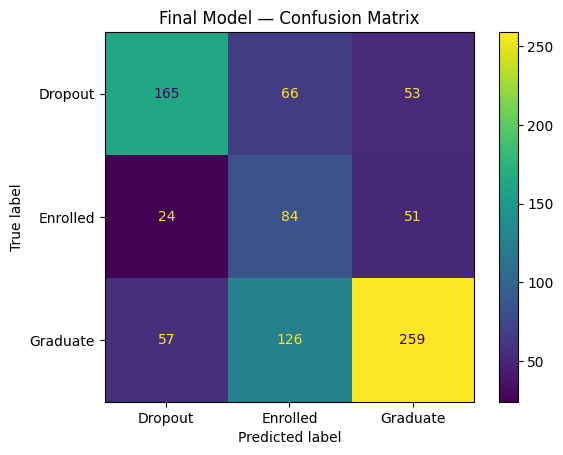

In [26]:
cm = confusion_matrix(y_test, y_pred, labels=final_model.classes_)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=final_model.classes_
)
disp.plot()
plt.title("Final Model — Confusion Matrix")
plt.show()

## 16. Final-model interpretation

For Logistic Regression, coefficients describe how each one-hot encoded category or scaled numerical variable contributes to the model's class score.

A large coefficient magnitude means the feature has a stronger association with that class **within this fitted model**. It does **not** prove causation.

In [27]:
# Inspect the largest absolute coefficients for each class
model_step = final_model.named_steps["model"]
prep_step = final_model.named_steps["preprocessor"]

feature_names = prep_step.get_feature_names_out()
coef = model_step.coef_

for class_name, class_coef in zip(model_step.classes_, coef):
    top_idx = np.argsort(np.abs(class_coef))[::-1][:10]

    print(f"\nTop coefficients for {class_name}:")
    display(pd.DataFrame({
        "Feature": feature_names[top_idx],
        "Coefficient": class_coef[top_idx]
    }).sort_values("Coefficient", key=np.abs, ascending=False))


Top coefficients for Dropout:


,Feature,Coefficient
0,categorical__Tuition fees up to date_0,0.787208
1,categorical__Tuition fees up to date_1,-0.781308
2,categorical__Mother's occupation_1,0.677316
3,categorical__Father's occupation_12,0.515532
4,categorical__Mother's occupation_12,0.509333
5,categorical__Mother's occupation_29,-0.454047
6,categorical__Application mode_4,0.448652
7,categorical__Course_12,-0.403177
8,categorical__Course_8,0.395729
9,categorical__Application mode_12,0.394937



Top coefficients for Enrolled:


,Feature,Coefficient
0,categorical__Mother's occupation_1,-0.714085
1,categorical__Course_7,0.641167
2,categorical__Mother's occupation_12,-0.564377
3,categorical__Father's occupation_12,-0.543328
4,categorical__Father's qualification_2,0.438954
5,categorical__Mother's occupation_29,0.434497
6,categorical__Father's occupation_1,-0.416834
7,categorical__Course_9,0.383190
8,categorical__Father's qualification_29,0.373541
9,categorical__Previous qualification_1,0.362072



Top coefficients for Graduate:


,Feature,Coefficient
0,categorical__Course_7,-0.748128
1,categorical__Tuition fees up to date_0,-0.612762
2,categorical__Tuition fees up to date_1,0.609592
3,categorical__Course_16,-0.505751
4,categorical__Course_10,0.452307
5,categorical__Course_12,0.426918
6,categorical__Application mode_12,-0.416295
7,categorical__Course_9,-0.401869
8,categorical__Application mode_6,0.378546
9,categorical__Course_4,0.378112


## 17. Save the complete trained pipeline

The saved artifact contains the **same preprocessing and model** used for prediction. This prevents the Streamlit application from reimplementing encoding/scaling separately and keeps inference consistent with training.


In [28]:
import os
import json
import joblib

MODEL_DIR = "models"
os.makedirs(MODEL_DIR, exist_ok=True)
MODEL_PATH = os.path.join(MODEL_DIR, "student_outcome_pipeline.joblib")
CONFIG_PATH = os.path.join(MODEL_DIR, "feature_config.json")

# Save the complete sklearn pipeline so the UI reuses exactly the same preprocessing + model.
joblib.dump(final_model, MODEL_PATH)

# Save the authoritative feature definition used by the notebook.
feature_config = {
    "target": target_column,
    "features": final_feature_columns,
    "categorical_features": categorical_features,
    "numeric_features": numeric_features,
    "excluded_for_temporal_leakage": temporal_leakage_features,
    "excluded_identifiers": identifier_features,
    "excluded_constant_features": constant_features,
}
with open(CONFIG_PATH, "w", encoding="utf-8") as f:
    json.dump(feature_config, f, indent=2)

print(f"Saved complete sklearn pipeline to: {MODEL_PATH}")
print(f"Saved feature configuration to: {CONFIG_PATH}")


Saved complete sklearn pipeline to: models/student_outcome_pipeline.joblib
Saved feature configuration to: models/feature_config.json


## 18. Final conclusions

The final model is selected using the **training-set cross-validation result, class-balanced evaluation, generalization considerations, and interpretability**, rather than simply choosing the largest test accuracy.

The held-out test set is used once for final reporting.

Remember: the model estimates associations in the supplied data. It does not establish that any feature causes a student's outcome.

## 19. Limitations

1. The dataset is observational; model associations are not causal effects.
2. The target classes are imbalanced, especially `Enrolled`.
3. The primary model intentionally excludes first- and second-semester curricular variables to avoid temporal leakage for an enrollment-time use case.
4. The supplied data alone does not establish how the model would perform on a different institution, year, or population.
5. Some integer-coded categories have many levels; one-hot encoding can increase dimensionality.
6. A production system would require monitoring, calibration, fairness checks, and validation on genuinely future data.

## 20. Future improvements

- Validate on a temporally separated future cohort.
- Compare performance under a clearly defined later prediction point using semester information.
- Tune decision thresholds if a particular class has a higher operational cost.
- Add probability calibration if predicted probabilities will drive interventions.
- Investigate subgroup performance and fairness.
- Consider model explanation tools such as SHAP only if they add value beyond the coefficient-based interpretation here.

# Project documentation

## 1. Dataset summary
- 4,424 observations
- 35 columns
- 34 predictors plus `Target`
- 3 target classes: Dropout, Enrolled, Graduate
- No missing values in the supplied dataset
- No duplicate rows in the supplied dataset

## 2. Problem statement
Build a multiclass classifier that predicts student outcome while avoiding temporal leakage and preserving the original observations.

## 3. EDA findings
- The target is imbalanced.
- Several integer columns are categorical codes rather than continuous measurements.
- Numerical variables require separate treatment from categorical codes.
- Student outcome appears associated with several administrative and demographic variables, but EDA does not establish causation.

## 4. Data-cleaning decisions
- No rows were artificially deleted.
- No missing values were inserted.
- No valid outliers were removed.
- No class was artificially balanced by deleting observations.

## 5. Feature audit and final modeling columns
- `Target` is the label, not a predictor.
- The 12 first/second-semester curricular-unit variables are excluded from the primary enrollment-time model because they are observed after enrollment.
- No identifier column is present in the supplied 35-column schema.
- No constant predictor is present.
- Near-constant binary indicators are retained because they are not constant and may contain predictive information.
- The remaining 22 predictors are retained and used consistently throughout the pipeline and UI.

## 6. Preprocessing
- One-hot encoding for categorical variables.
- Standard scaling for numerical variables.
- All preprocessing is inside a pipeline.

## 7. Train/test strategy
- 80/20 split.
- Stratified by target.
- `random_state=42`.

## 8. Models tested
- DummyClassifier
- Logistic Regression
- Decision Tree
- Random Forest
- Gradient Boosting

## 9. Evaluation
Accuracy, macro precision, macro recall, macro F1, weighted F1, classification report, and confusion matrix.

## 10. Cross-validation
Five-fold Stratified K-Fold on the training data, reporting mean and standard deviation.

## 11. Hyperparameter tuning
Grid search over Logistic Regression `C`, scored using macro F1, with class balancing.

## 12. Final model
The tuned Logistic Regression pipeline is the documented final model for the early-warning objective.

## 13. Important features
Use the coefficient table generated in the final interpretation section. Coefficients indicate model association, not causation.

## 14. Limitations
See the limitations section above.

## 15. Future improvements
See the future-improvements section above.

# Resume project description

**Student Outcome Classification — Machine Learning**
- Built a leakage-aware multiclass classification pipeline to predict student outcomes (`Dropout`, `Enrolled`, `Graduate`) from 4,424 records.
- Performed data-quality auditing, target analysis, meaningful EDA, categorical encoding, scaling, stratified train/test splitting, cross-validation, and hyperparameter tuning.
- Compared baseline, linear, tree-based, and ensemble classifiers using macro F1 and class-wise evaluation rather than accuracy alone.
- Used an sklearn `Pipeline`/`ColumnTransformer` workflow to prevent preprocessing leakage and interpreted the final Logistic Regression model using class coefficients.

# GitHub README outline

1. Project title
2. Problem statement
3. Dataset description
4. Objective and prediction-time definition
5. Leakage considerations
6. Data-quality audit
7. EDA
8. Feature engineering / preprocessing
9. Modeling approach
10. Evaluation metrics
11. Cross-validation
12. Hyperparameter tuning
13. Final model
14. Interpretation
15. Limitations
16. Future work
17. How to run the notebook
18. License / dataset attribution if required

# Viva explanation

**Q: What problem did you solve?**  
A: I treated student outcome as a three-class classification problem: Dropout, Enrolled, or Graduate.

**Q: Why didn't you use accuracy alone?**  
A: The classes are imbalanced, so accuracy can hide weak performance on the smaller class. I therefore emphasized macro F1 and class-wise precision/recall.

**Q: Why are many integer columns encoded as categorical?**  
A: Their numeric values are codes for categories. The difference between code 2 and code 3 does not necessarily represent a meaningful numerical distance.

**Q: What is data leakage in this project?**  
A: Semester-performance variables are observed after enrollment. Using them for an enrollment-time prediction would give the model information that would not be available when the prediction is supposed to be made.

**Q: Why use a pipeline?**  
A: It keeps preprocessing and modeling together and ensures transformations are fitted only on the relevant training folds.

**Q: Why use stratification?**  
A: It keeps the class proportions reasonably similar across the training and test sets.

**Q: Why use macro F1?**  
A: It gives each class equal importance, which is useful when one class is much smaller.

**Q: Does feature importance prove causation?**  
A: No. It describes the model's learned association and contribution to prediction, not a causal relationship.

# Interview explanation

A concise project explanation:

> I developed a multiclass student-outcome classifier using a 4,424-row dataset with 35 columns. I first audited data quality and discovered that many integer columns were categorical codes. I preserved the original data because there were no missing values or duplicates requiring deletion. I also identified a temporal-leakage issue: first- and second-semester curricular variables are not appropriate for an enrollment-time early-warning model, so I excluded them from the primary model. I used a stratified 80/20 split, a ColumnTransformer with one-hot encoding and scaling, and compared several baseline and ML models. I evaluated them using accuracy, macro precision, macro recall, macro F1, weighted F1, and a confusion matrix, then used five-fold stratified cross-validation and a small GridSearchCV for Logistic Regression. The final workflow is reproducible, leakage-aware, and interpretable rather than optimized only for accuracy.